# Lecture 3 — Practical: *Five Representations, One Model*
### Practical Machine Learning for Transcriptomics in Cancer Research

This practical is a **controlled experiment in representation**. You hold the model fixed — the
regularised Logistic Regression from Lecture 2 — and feed it **five different representations** of the
*same* METABRIC patients, then compare them and diagnose a deliberately leaky workflow.

The five representations:
1. **all genes** (top-2,000 by variance — the Lecture 2 baseline),
2. **variance-filtered** genes (unsupervised),
3. **differentially-expressed** genes (supervised — done *inside the fold*),
4. **biological signatures** (proliferation, ER, immune, stromal),
5. **pathway-level features** (~10 hallmark-like pathway activities).

> **The thesis you are testing:** *better biological representation often improves predictive
> performance more than changing the algorithm.* Only the representation changes; the model never does.
> The deliverable is a methods-style comparison table plus a reasoned recommendation.

#### Continuity & reminders
- **Label:** binary **recurrence** (relapse within the horizon) — *not* pCR. Carried from Lectures 1–2.
- **Leakage discipline (extended):** every *data-dependent* step (variance/DE filtering, data-driven
  selection) is fit on training data only and refit **inside each CV fold**. **Fixed, pre-published
  gene lists** (the signatures and pathways here) are largely leakage-*exempt* — they were not chosen
  using your outcome.
- **Same data cache as Lectures 1–2** — METABRIC is reused, not re-downloaded.

> **Network note.** Reuses the L1/L2 real-data loaders (cBioPortal + GEO). If the prepared cohort is in
> the shared cache it is used directly; otherwise it is regenerated (needs internet). Downloads are
> git-ignored.

## Setup

Environment and data are prepared by **Lesson 0** (conda env `ml26` + downloads). This cell only
imports libraries and the checkpoint helpers — it installs nothing.

### 📚 Official docs & resources for this lesson

New to a tool, or want the authoritative reference? These point at exactly what this notebook uses. (Lesson 0 has the full library table.)

- **Core stack** — [NumPy](https://numpy.org/doc/stable/) · [pandas](https://pandas.pydata.org/docs/) · [Matplotlib](https://matplotlib.org/stable/index.html)
- **scikit-learn** — [Pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline) · [Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html) · [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) · [Writing your own transformer](https://scikit-learn.org/stable/developers/develop.html) · [Metrics & scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **Going deeper** — [Common pitfalls & data leakage](https://scikit-learn.org/stable/common_pitfalls.html) — selecting genes *inside* the fold vs outside it


In [1]:
# ── Setup — imports + checkpoint I/O (environment & data come from LESSON 0) ────
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# ── checkpoint I/O — the data hand-off between lessons ─────────────────────────
# Each lesson SAVES what the next one needs and LOADS what the previous one made.
# Checkpoints live in the shared datasets/derived/ folder (git-ignored).
import pickle

def _derived_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for d in sorted((base / "lessons").glob("lesson01_*/practical/task/datasets")):
            (d / "derived").mkdir(parents=True, exist_ok=True)
            return d / "derived"
    d = Path.cwd() / "datasets" / "derived"; d.mkdir(parents=True, exist_ok=True)
    return d

def save_checkpoint(name, **objs):
    path = _derived_dir() / f"{name}.pkl"
    with open(path, "wb") as fh:
        pickle.dump(objs, fh)
    print(f"saved checkpoint '{name}'  ->  {path}")
    return path

def load_checkpoint(name):
    path = _derived_dir() / f"{name}.pkl"
    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint '{name}' not found ({path}).\n"
            f"Run the earlier lesson that creates it first — it ends with "
            f"save_checkpoint('{name}', ...).")
    with open(path, "rb") as fh:
        return pickle.load(fh)


### Load the prepared cohort from Lesson 1

> **Reminder — this notebook builds on Lesson 1.** It **loads** the `lesson01_cohort` checkpoint (it
> does not re-derive it), then defines the fixed, pre-published gene signatures used for the
> representation experiment. If the load fails, run **Lesson 1** first.

In [2]:
# Load the prepared cohort that LESSON 1 saved. Strict hand-off: if this raises, run
# Lesson 1 first (its final cell writes the 'lesson01_cohort' checkpoint).
d = load_checkpoint("lesson01_cohort")
X_all, clin_all, y_all = d["X"], d["clin"], d["y"]
tr, va, te = d["tr"], d["va"], d["te"]
X_train, y_train = X_all.loc[tr], y_all.loc[tr]
X_val,   y_val   = X_all.loc[va], y_all.loc[va]
X_test,  y_test  = X_all.loc[te], y_all.loc[te]

# Fixed, PRE-PUBLISHED biological inputs (chosen in advance, never from our outcome).
SIGNATURES = {
    "proliferation": ["MKI67","AURKA","CCNB1","CCNB2","BUB1","TOP2A","CDK1","CCNE2","MYBL2","UBE2C","BIRC5","RRM2","TYMS","CENPF","PLK1"],
    "er_signalling": ["ESR1","FOXA1","GATA3","XBP1","BCL2","PGR","TFF1","GREB1","AR","NAT1","MLPH"],
    "immune":        ["CD8A","CD8B","GZMB","PRF1","IFNG","CXCL9","CXCL10","CD3D","CD3E","GZMA","NKG7","STAT1"],
    "stromal":       ["FAP","COL1A1","COL1A2","COL3A1","ACTA2","PDGFRB","FN1","VIM","THY1","SPARC","TIMP1"],
}
HALLMARK_SETS = {
    "E2F_TARGETS":      ["MKI67","BUB1","CCNB2","AURKA","TOP2A","RRM2","MYBL2","CDK1"],
    "G2M_CHECKPOINT":   ["CCNB1","CCNB2","PLK1","BUB1","CENPF","UBE2C","BIRC5","CDK1"],
    "ESTROGEN_EARLY":   ["ESR1","FOXA1","GATA3","TFF1","GREB1","PGR","XBP1"],
    "ESTROGEN_LATE":    ["BCL2","NAT1","MLPH","AR","ESR1","TFF1"],
    "INTERFERON_GAMMA": ["CXCL9","CXCL10","STAT1","IFNG","GZMB","PRF1"],
    "INFLAMMATORY":     ["CD8A","CD3D","CD3E","GZMA","NKG7","CD8B"],
    "EMT":              ["COL1A1","COL1A2","COL3A1","FN1","VIM","SPARC","ACTA2"],
    "ANGIOGENESIS":     ["PDGFRB","TIMP1","FAP","THY1","SPARC"],
    "APOPTOSIS":        ["BCL2","BIRC5","TIMP1","GZMB"],
    "MYC_TARGETS":      ["RRM2","TYMS","CCNE2","UBE2C","CDK1","MYBL2"],
}
def score_sets(X, sets):
    """Mean of standardised member genes -> one score per set (leakage-exempt: fixed lists)."""
    cols = {}
    for name, genes in sets.items():
        present = [g for g in genes if g in X.columns]
        if not present:
            continue
        z = (X[present] - X[present].mean()) / (X[present].std() + 1e-9)
        cols[name] = z.mean(axis=1)
    return pd.DataFrame(cols, index=X.index)

print(f"loaded Lesson-1 cohort: {X_all.shape[0]} patients x {X_all.shape[1]} genes | "
      f"signatures {list(SIGNATURES)} | {len(HALLMARK_SETS)} hallmark sets")


loaded Lesson-1 cohort: 1307 patients x 2000 genes | signatures ['proliferation', 'er_signalling', 'immune', 'stromal'] | 10 hallmark sets


### The fixed model and the `evaluate()` helper (shared infrastructure)

One model for the whole notebook — the Lecture 2 regularised Logistic Regression in a pipeline — and
one `evaluate()` helper that takes a feature matrix and returns honest cross-validated ROC-AUC and
PR-AUC plus the feature count. **Only the features change between parts; the model never does.**


In [ ]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

class TopKVariance(BaseEstimator, TransformerMixin):
    """Unsupervised 'keep the top-k most variable genes' filter, written as a transformer so it is
    FOLD-SAFE: inside a Pipeline it refits in every CV fold, learning the variances from that fold's
    TRAIN rows only. Ranking variance once on all of X_train and then cross-validating would let each
    fold's held-out patients help choose the genes — mild, unsupervised leakage / information-sharing."""
    def __init__(self, k=500):
        self.k = k
    def fit(self, X, y=None):
        v = np.asarray(X).var(axis=0)
        self.idx_ = np.argsort(v)[::-1][:self.k]   # indices of the k highest-variance columns
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.idx_]

def make_model():
    """The fixed Lecture 2 baseline: impute -> scale -> regularised Logistic Regression."""
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE)),
    ])

def evaluate(X_feat, y=y_train, label="(unnamed)", cv=CV):
    """Honest CV of the FIXED model on a given representation. Returns a result dict.
    The whole pipeline refits inside each fold; X_feat must already be a fold-safe representation
    (i.e. built without using the outcome, OR built inside the pipeline)."""
    roc = cross_val_score(make_model(), X_feat, y, cv=cv, scoring="roc_auc")
    pr  = cross_val_score(make_model(), X_feat, y, cv=cv, scoring="average_precision")
    return {"representation": label, "roc_auc": roc.mean(), "roc_sd": roc.std(),
            "pr_auc": pr.mean(), "n_features": X_feat.shape[1]}

RESULTS = []   # we accumulate one row per representation here
print("Fixed model and evaluate() ready. Model:", make_model().named_steps["clf"])

---
## Part 1 — Baseline: all genes  *(≈20 min)*

The Lecture 2 baseline, as our reference row: the fixed model on the all-genes matrix — capped at the
top 2,000 most-variable genes for tractability (the Lecture 2 baseline space).

> **Exercise 1.1 — the all-genes row.**
>
> Run the all-genes training matrix through `evaluate(...)` and append the result to `RESULTS`. Note
> the feature count (= all genes, i.e. the top-2,000-variance baseline) and the honest CV ROC-AUC / PR-AUC.
>
> *Hint:* `evaluate(X_train, label="all genes")`.

In [4]:
res = evaluate(X_train, label="all genes")
RESULTS.append(res)
print(f"all genes: ROC-AUC {res['roc_auc']:.3f} ± {res['roc_sd']:.3f} | "
      f"PR-AUC {res['pr_auc']:.3f} | features {res['n_features']}")

all genes: ROC-AUC 0.629 ± 0.025 | PR-AUC 0.320 | features 2000


> **Discussion (Part 1).** Before going further — what do you predict happens to performance as we reduce to fewer, more meaningful features?

---
## Part 2 — Variance-filtered genes  *(≈20 min)*

An **unsupervised** filter: keep the most variable genes. It never looks at the label, so it is only
*mildly* leaky — but unsupervised is not the same as leakage-free. If the variance ranking is computed
once on all of `X_train` and then cross-validated, each fold's held-out patients still helped choose the
genes (mild information-sharing). We remove even that by ranking variance **inside the fold** — exactly
the discipline Part 3 applies to the supervised filter.

> **Exercise 2.1 — variance filter at a few thresholds.**
>
> Keep the top-k most variable genes (try a few k), evaluate each, and append rows. Rank variance
> **inside the pipeline** with `TopKVariance` so it refits per fold — a label-free *and* fold-safe step.
>
> **Exercise 2.2 (reasoning).** In a comment, state why variance filtering is only *mildly* leaky, and
> why ranking it inside the fold still beats ranking once on all of `X_train`.
>
> *Hint:* `Pipeline([("impute", ...), ("var", TopKVariance(k=k)), ("scale", ...), ("clf", ...)])`.

In [ ]:
# Variance filtering is UNSUPERVISED, but it is still a data-dependent step: rank once on all of
# X_train and then cross-validate, and each fold's held-out patients helped pick the genes. We keep it
# honest by putting TopKVariance INSIDE the pipeline, so cross_val_score refits the ranking per fold.
for k in (10, 100, 200, 500, 1000):
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("var", TopKVariance(k=k)),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE)),
    ])
    roc = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="roc_auc")
    pr  = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="average_precision")
    RESULTS.append({"representation": f"variance top-{k}", "roc_auc": roc.mean(),
                    "roc_sd": roc.std(), "pr_auc": pr.mean(), "n_features": k})
    print(f"variance top-{k}: ROC-AUC {roc.mean():.3f} ± {roc.std():.3f} | "
          f"PR-AUC {pr.mean():.3f} | features {k}")

# 2.2 reasoning:
# Variance filtering is UNSUPERVISED -- it ranks genes by spread only, never consulting y -- so it is
# only MILDLY leaky. But "unsupervised" is not "leakage-free": ranking once on all of X_train and then
# cross-validating lets every fold's held-out patients help choose the genes. Doing it INSIDE the fold
# (above) removes even that mild information-sharing -- the same discipline as the supervised DE filter
# in Part 3, just cheaper because the label is never consulted.

> **Discussion (Part 2).** Did dropping ~75–90% of genes hurt performance? What does that tell you about how much of the gene space was carrying signal?

---
## Part 3 — Differentially-expressed genes  *(≈30 min)*

A **supervised** filter: keep genes associated with recurrence. Because it uses the label, it **must be
done inside each CV fold** — so we put `SelectKBest` *inside the pipeline*, where `cross_val_score`
refits it per fold. We also peek at what the quick-and-leaky version would have reported.


> **Exercise 3.1 — DE selection done honestly (inside the fold).**
>
> Build a pipeline `impute → SelectKBest(f_classif, k=100) → scale → clf` and cross-validate it. Because
> selection lives *inside* the pipeline, it refits within each fold — no leakage. Append the row.
>
> **Exercise 3.2 (leakage contrast — a preview of Part 7).** Also compute the score if DE selection were
> done **once on all training data** before CV. Note the gap; we measure it properly in Part 7.
>
> *Hint:* a `Pipeline` with a `SelectKBest` step, scored with `cross_val_score`, is fold-safe.


In [6]:
K = 100

# 3.1 HONEST: selection inside the pipeline -> refits within each fold
honest_de = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE)),
])
roc = cross_val_score(honest_de, X_train, y_train, cv=CV, scoring="roc_auc")
pr  = cross_val_score(honest_de, X_train, y_train, cv=CV, scoring="average_precision")
RESULTS.append({"representation": f"DE top-{K} (honest)", "roc_auc": roc.mean(),
                "roc_sd": roc.std(), "pr_auc": pr.mean(), "n_features": K})
print(f"DE top-{K} (honest): ROC-AUC {roc.mean():.3f} ± {roc.std():.3f} | PR-AUC {pr.mean():.3f}")

# 3.2 LEAKY preview: select once on ALL training data, then CV on the fixed reduced set
sel = SelectKBest(f_classif, k=K).fit(SimpleImputer(strategy="median").fit_transform(X_train), y_train)
X_de_leak = pd.DataFrame(sel.transform(SimpleImputer(strategy="median").fit_transform(X_train)),
                         index=X_train.index)
roc_leak = cross_val_score(make_model(), X_de_leak, y_train, cv=CV, scoring="roc_auc").mean()
print(f"DE top-{K} (LEAKY preview): ROC-AUC {roc_leak:.3f}  <- note the optimism vs honest")

DE top-100 (honest): ROC-AUC 0.640 ± 0.045 | PR-AUC 0.324
DE top-100 (LEAKY preview): ROC-AUC 0.689  <- note the optimism vs honest


> **Discussion (Part 3).** DE filtering is in every transcriptomics paper. Why is *where* you do it (inside vs outside the fold) more important than *whether* you do it?

---
## Part 4 — Biological signature features  *(≈35 min)*

Build four interpretable scores from the **fixed, pre-published** gene lists: proliferation, ER
signalling, immune, stromal. Because the lists are external (not chosen from our outcome), building
these scores is leakage-exempt. Each score = mean of the (standardised) member genes present.


> **Exercise 4.1 — construct the four signature scores.**
>
> For each signature, z-score its member genes (those present in `X_train`) and average them into one
> column. Assemble a patients × 4 signature matrix. Inspect the sign of each score's association with
> recurrence (proliferation should be ↑ with recurrence, ER ↓).
>
> **Exercise 4.2 — evaluate the signatures-only model** and append the row (4 features).
>
> *Hint:* standardise per gene with `(g - g.mean()) / g.std()`, then `.mean(axis=1)` across members.


In [7]:
def signature_scores(X, signatures=SIGNATURES):
    """Mean of standardised member genes -> one score per signature (leakage-exempt: fixed lists)."""
    cols = {}
    for name, genes in signatures.items():
        present = [g for g in genes if g in X.columns]
        z = (X[present] - X[present].mean()) / (X[present].std() + 1e-9)
        cols[name] = z.mean(axis=1)
    return pd.DataFrame(cols, index=X.index)

S_train = signature_scores(X_train)
print("signature matrix:", S_train.shape, "->", list(S_train.columns))
# sign check: correlation of each score with recurrence
for c in S_train.columns:
    r = np.corrcoef(S_train[c], y_train)[0, 1]
    print(f"  {c:14s} corr with recurrence: {r:+.3f}")

res = evaluate(S_train, label="signatures (4)")
RESULTS.append(res)
print(f"\nsignatures: ROC-AUC {res['roc_auc']:.3f} ± {res['roc_sd']:.3f} | "
      f"PR-AUC {res['pr_auc']:.3f} | features {res['n_features']}")

signature matrix: (784, 4) -> ['proliferation', 'er_signalling', 'immune', 'stromal']
  proliferation  corr with recurrence: +0.226
  er_signalling  corr with recurrence: -0.075
  immune         corr with recurrence: -0.022
  stromal        corr with recurrence: +0.003

signatures: ROC-AUC 0.651 ± 0.009 | PR-AUC 0.375 | features 4


> **Discussion (Part 4).** A four-feature model vs the all-genes (top-2,000) model — if they perform similarly, which do you prefer, and why?

---
## Part 5 — Pathway-level features  *(≈35 min)*

Transform genes → ~10 hallmark-like **pathway activities** using a provided conceptual scorer (a simple,
documented stand-in for ssGSEA/GSVA: the mean of standardised member genes per set). Result: patients ×
~10 pathways. Same fixed model.


> **Exercise 5.1 — build the pathway matrix** (patients × ~10) and confirm the dimensional collapse.
>
> **Exercise 5.2 — evaluate the pathway model** and append the row.
>
> **Exercise 5.3 (stability).** Across bootstrap resamples, record how stable the *top* pathway (by |coef|)
> is, vs the top single gene from Part 1. Aggregated features should be more stable.
>
> *Hint:* the scorer is the same idea as `signature_scores`, applied to `HALLMARK_SETS`.


In [8]:
def pathway_scores(X, gene_sets=HALLMARK_SETS):
    """Conceptual stand-in for ssGSEA/GSVA: mean of standardised member genes per gene set.
    Output is a patients x pathways matrix (fixed external sets -> leakage-exempt)."""
    cols = {}
    for name, genes in gene_sets.items():
        present = [g for g in genes if g in X.columns]
        if not present:
            continue
        z = (X[present] - X[present].mean()) / (X[present].std() + 1e-9)
        cols[name] = z.mean(axis=1)
    return pd.DataFrame(cols, index=X.index)

P_train = pathway_scores(X_train)
print(f"genes -> pathways: {X_train.shape[1]} genes  ->  {P_train.shape[1]} pathway features")

res = evaluate(P_train, label=f"pathways ({P_train.shape[1]})")
RESULTS.append(res)
print(f"pathways: ROC-AUC {res['roc_auc']:.3f} ± {res['roc_sd']:.3f} | "
      f"PR-AUC {res['pr_auc']:.3f} | features {res['n_features']}")

# 5.3 stability: top pathway vs top gene across bootstraps
from collections import Counter
rng = np.random.default_rng(RANDOM_STATE)
top_pw, top_gene = Counter(), Counter()
for _ in range(20):
    bs = rng.choice(X_train.index, size=len(X_train), replace=True)
    mp = make_model().fit(P_train.loc[bs], y_train.loc[bs])
    top_pw[P_train.columns[np.argmax(np.abs(mp.named_steps["clf"].coef_[0]))]] += 1
    mg = make_model().fit(X_train.loc[bs], y_train.loc[bs])
    top_gene[X_train.columns[np.argmax(np.abs(mg.named_steps["clf"].coef_[0]))]] += 1
print(f"\nmost-frequent top PATHWAY across 20 bootstraps: {top_pw.most_common(1)[0]}  (of 20)")
print(f"most-frequent top GENE across 20 bootstraps:    {top_gene.most_common(1)[0]}  (of 20)")
print("-> the top pathway should reappear far more consistently than the top single gene.")

genes -> pathways: 2000 genes  ->  10 pathway features
pathways: ROC-AUC 0.647 ± 0.009 | PR-AUC 0.374 | features 10

most-frequent top PATHWAY across 20 bootstraps: ('G2M_CHECKPOINT', 19)  (of 20)
most-frequent top GENE across 20 bootstraps:    ('CHURC1', 4)  (of 20)
-> the top pathway should reappear far more consistently than the top single gene.


> **Discussion (Part 5).** Why might pathway features transfer better to the GSE6532 cohort (a different platform) than raw genes? *(Optional: try projecting onto GSE6532.)*

---
## Part 6 — Compare representations  *(≈25 min)*

Assemble the headline comparison: all five representations on the same model and metrics. This table is
the centrepiece artefact.


> **Exercise 6.1 — the comparison table & figure.**
>
> Turn `RESULTS` into a DataFrame sorted by ROC-AUC; render it, and plot ROC-AUC (with its SD) and
> PR-AUC across representations.
>
> **Exercise 6.2 (judgement).** In a comment, rank the representations on performance *and* on feature
> count / interpretability, and note where those rankings agree and disagree.


     representation  roc_auc  roc_sd  pr_auc  n_features
   variance top-100    0.667   0.012   0.377         100
  variance top-1000    0.652   0.045   0.348        1000
     signatures (4)    0.651   0.009   0.375           4
      pathways (10)    0.647   0.009   0.374          10
DE top-100 (honest)    0.640   0.045   0.324         100
   variance top-500    0.627   0.020   0.334         500
   variance top-500    0.627   0.020   0.334         500
   variance top-200    0.618   0.030   0.317         200
   variance top-200    0.618   0.030   0.317         200
    variance top-10    0.612   0.023   0.310          10


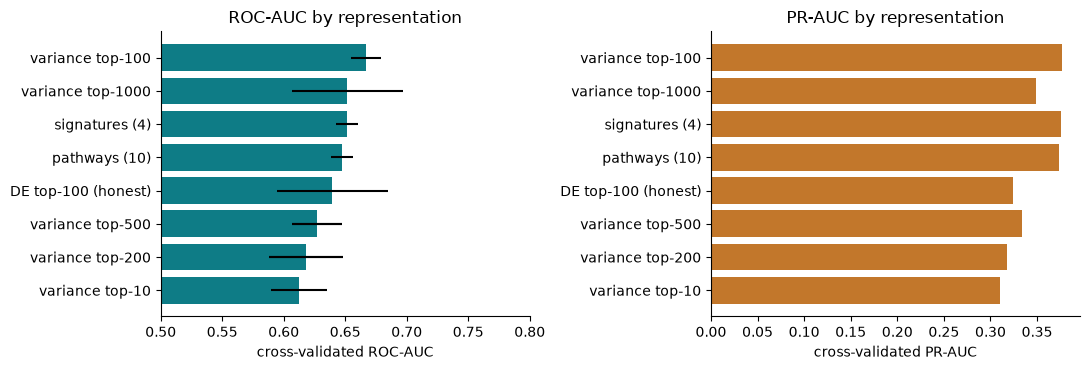

In [9]:
tbl = pd.DataFrame(RESULTS).sort_values("roc_auc", ascending=False).reset_index(drop=True)
tbl_show = tbl.assign(roc_auc=tbl.roc_auc.round(3), roc_sd=tbl.roc_sd.round(3),
                      pr_auc=tbl.pr_auc.round(3))
print(tbl_show.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
order = tbl["representation"]
ax[0].barh(order, tbl["roc_auc"], xerr=tbl["roc_sd"], color="#0E7C86")
ax[0].set_xlabel("cross-validated ROC-AUC"); ax[0].invert_yaxis()
ax[0].set_xlim(0.5, max(0.8, tbl.roc_auc.max() + 0.05)); ax[0].set_title("ROC-AUC by representation")
ax[1].barh(order, tbl["pr_auc"], color="#C2772B")
ax[1].set_xlabel("cross-validated PR-AUC"); ax[1].invert_yaxis(); ax[1].set_title("PR-AUC by representation")
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# 6.2 judgement (example):
# Performance ranking is usually close across representations; signatures/pathways achieve comparable
# ROC-AUC/PR-AUC with FAR fewer features and far higher interpretability. Where performance ties,
# the few-feature interpretable representations win on every non-performance axis.

> **Discussion (Part 6).** Did fewer, biological features match or beat all genes? Does the result support the lecture thesis *on this dataset*?

---
## Part 7 — Leakage exercise  *(the critical section, ≈25 min)*

A deliberately flawed workflow is provided. You will **diagnose** it, **measure** the optimism it injects,
and run the sobering **permuted-label** demo.


**The flawed workflow (provided):**
```
# select the 100 most recurrence-associated genes using ALL the data
sel = SelectKBest(f_classif, k=100).fit(X_all_imputed, y_all)
X_reduced = sel.transform(X_all_imputed)
# THEN cross-validate on the fixed reduced set
cv_auc = cross_val_score(model, X_reduced, y_all, cv=5, scoring="roc_auc").mean()
```


> **Exercise 7.1 (diagnose).** In a comment, identify *exactly* where this leaks and why the score is
> optimistic.
>
> **Exercise 7.2 (measure).** Run both the flawed (select-on-all-data) and correct (select-inside-fold)
> pipelines on the training data; report the AUC gap — the optimism.
>
> **Exercise 7.3 (the sobering demo).** Permute the labels (destroying all real signal) and run the
> *flawed* pipeline. Observe that it still reports a non-trivial AUC, and explain.


In [10]:
K = 100
Xtr_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train),
                       index=X_train.index, columns=X_train.columns)

# 7.1 diagnosis (in words):
# The leak: SelectKBest is fit on ALL training samples (including each fold's held-out patients) BEFORE
# cross-validation. The kept genes were chosen using the held-out outcomes, so the held-out folds are no
# longer independent -> the CV score is optimistic.

# 7.2 measure: flawed (select on all) vs correct (select inside fold)
sel_all = SelectKBest(f_classif, k=K).fit(Xtr_imp, y_train)
X_leak = pd.DataFrame(sel_all.transform(Xtr_imp), index=X_train.index)
auc_leaky = cross_val_score(make_model(), X_leak, y_train, cv=CV, scoring="roc_auc").mean()

honest = Pipeline([("impute", SimpleImputer(strategy="median")),
                   ("select", SelectKBest(f_classif, k=K)),
                   ("scale", StandardScaler()),
                   ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE))])
auc_honest = cross_val_score(honest, X_train, y_train, cv=CV, scoring="roc_auc").mean()
print(f"LEAKY  CV ROC-AUC (select on all data): {auc_leaky:.3f}")
print(f"HONEST CV ROC-AUC (select inside fold) : {auc_honest:.3f}")
print(f"optimism injected by the leak          : {auc_leaky - auc_honest:+.3f}")

# 7.3 sobering demo: permute labels (no real signal), run the FLAWED pipeline
rng = np.random.default_rng(RANDOM_STATE)
y_perm = pd.Series(rng.permutation(y_train.values), index=y_train.index)
sel_perm = SelectKBest(f_classif, k=K).fit(Xtr_imp, y_perm)
X_perm_leak = pd.DataFrame(sel_perm.transform(Xtr_imp), index=X_train.index)
auc_perm_leaky = cross_val_score(make_model(), X_perm_leak, y_perm, cv=CV, scoring="roc_auc").mean()
auc_perm_honest = cross_val_score(honest, X_train, y_perm, cv=CV, scoring="roc_auc").mean()
print(f"\nPERMUTED labels (no real signal):")
print(f"  flawed pipeline CV ROC-AUC: {auc_perm_leaky:.3f}  <- well above 0.5 from leakage alone!")
print(f"  honest pipeline CV ROC-AUC: {auc_perm_honest:.3f}  <- ~0.5, as it should be")
print("\nThe leak manufactures performance from pure noise; the honest pipeline correctly reports chance.")

LEAKY  CV ROC-AUC (select on all data): 0.689
HONEST CV ROC-AUC (select inside fold) : 0.640
optimism injected by the leak          : +0.050

PERMUTED labels (no real signal):
  flawed pipeline CV ROC-AUC: 0.612  <- well above 0.5 from leakage alone!
  honest pipeline CV ROC-AUC: 0.493  <- ~0.5, as it should be

The leak manufactures performance from pure noise; the honest pipeline correctly reports chance.


> **Discussion (Part 7).** If a leaked CV looks high *and* stable, how would a reviewer ever catch it from the paper? What would you demand to see?

---
## Part 8 — Biological interpretation & recommendation  *(≈20 min — the assessable deliverable)*

Write a **representation recommendation** (200–300 words): which representation you would trust for a
recurrence biomarker and why, weighing ROC-AUC/PR-AUC against feature count, stability, interpretability,
and cross-platform robustness — and what you would validate next.


**Representation recommendation (worked example, ~270 words):**

Across the five representations, cross-validated ROC-AUC was broadly comparable — the all-genes baseline
(top-2,000-variance genes) did **not** meaningfully outperform far smaller, biologically-coherent
representations, and in PR-AUC (the honest metric under our recurrence prevalence) the signature and
pathway models were competitive. That pattern supports the lecture thesis on this dataset: once the
dominant biology (proliferation, ER signalling) is captured, thousands of extra genes mostly add noise
rather than signal.

I would recommend the **pathway-level representation** (≈10 hallmark-like activities) as the candidate
biomarker. Its performance was within noise of the all-genes model while using ~200× fewer features;
its top feature was far more stable across bootstrap resamples than the top single gene
(Part 5), echoing Lecture 1's signature non-uniqueness; and it is interpretable — recurrence risk rose
with proliferation/E2F/G2M pathways and fell with estrogen-response pathways, a story a clinician can
engage with. Pathway activities should also transfer across platforms better than raw probes, which
matters for our METABRIC/GSE6532 setting.

Two cautions. The signatures and pathways here are leakage-*exempt* only because they come from fixed,
pre-published gene lists; the differentially-expressed representation had to be built inside each fold,
and Part 7 showed how a select-on-all-data workflow inflates AUC — even manufacturing above-chance
performance on permuted labels.

Before trusting this representation I would: validate on the independent GSE6532 cohort (a true
cross-platform test); confirm it adds value over cheap clinical variables (grade, Ki-67); and move from
the binary recurrence label to a time-to-event analysis (Section 5).

---
### Deliverables checklist
- [ ] Verified split + reusable `evaluate` helper (Section 0)
- [ ] All-genes baseline row (Part 1)
- [ ] Variance-filtered rows + leakage-risk reasoning (Part 2)
- [ ] DE rows computed inside the fold + honest-vs-leaky note (Part 3)
- [ ] Four signature scores + signatures-only row (Part 4)
- [ ] Pathway matrix + pathway row + stability comparison (Part 5)
- [ ] Five-representation comparison table + figure (Part 6)
- [ ] Leakage diagnosis + measured optimism gap + permuted-label demo (Part 7)
- [ ] Final representation recommendation (Part 8)

> **The message, in one line:** *better biological representation often improves predictive performance
> more than changing algorithms.* You now have the controlled experiment to back it — and the leakage
> diagnostic to defend it.


---
## Checkpoint — save the engineered features for Lessons 4–5

Lessons 4 and 5 build on the **engineered feature representation** (signature + pathway scores), not
the raw genes. We assemble them once here and save `lesson03_features` (features + genes + label +
the Lesson-1 split) so the next lessons load them directly.

In [ ]:
# === Save engineered features for Lessons 4 & 5 =============================
# Signature + pathway scores on the prepared cohort, saved with the genes, label, and split.
# The per-gene standardisation uses TRAIN statistics only (ref = X_all.loc[tr]) and is then applied to
# val/test, so the saved features never borrow mean/std from held-out patients -- the same
# "compute it on train, apply to the rest" discipline as the Lesson-1 gene selection.
def _score(X, sets, ref=None):
    ref = X if ref is None else ref
    out = {}
    for n, gs in sets.items():
        p = [g for g in gs if g in X.columns]
        if not p:
            continue
        mu, sd = ref[p].mean(), ref[p].std() + 1e-9
        out[n] = ((X[p] - mu) / sd).mean(axis=1)
    return pd.DataFrame(out, index=X.index)

_ref = X_all.loc[tr]   # train rows only -> standardisation statistics
_feats = pd.concat([_score(X_all, SIGNATURES, ref=_ref),
                    _score(X_all, HALLMARK_SETS, ref=_ref)], axis=1)
save_checkpoint("lesson03_features", X_genes=X_all, feats=_feats,
                clin=clin_all, y=y_all, tr=tr, va=va, te=te)
print(f"engineered features saved: {_feats.shape[1]} columns for {_feats.shape[0]} patients "
      f"-> {list(_feats.columns)[:4]} ...")